# Task 5: Decision Trees and Random Forests

## Objective
To learn tree-based machine learning models for classification and understand how Random Forest improves upon Decision Trees.

## Tools Used
- Python
- Scikit-learn
- Matplotlib
- Pandas

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

## Loading Dataset

For this task, we use the Breast Cancer dataset available in Scikit-Learn. The goal is to predict whether a tumor is malignant or benign.

In [11]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Splitting Dataset

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 455
Testing Samples: 114


## Training a Decision Tree Classifier

A Decision Tree creates a set of rules to classify data points.

In [13]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))

Decision Tree Accuracy: 0.9474


## Visualizing the Decision Tree

The visualization helps us understand how the Decision Tree makes decisions.

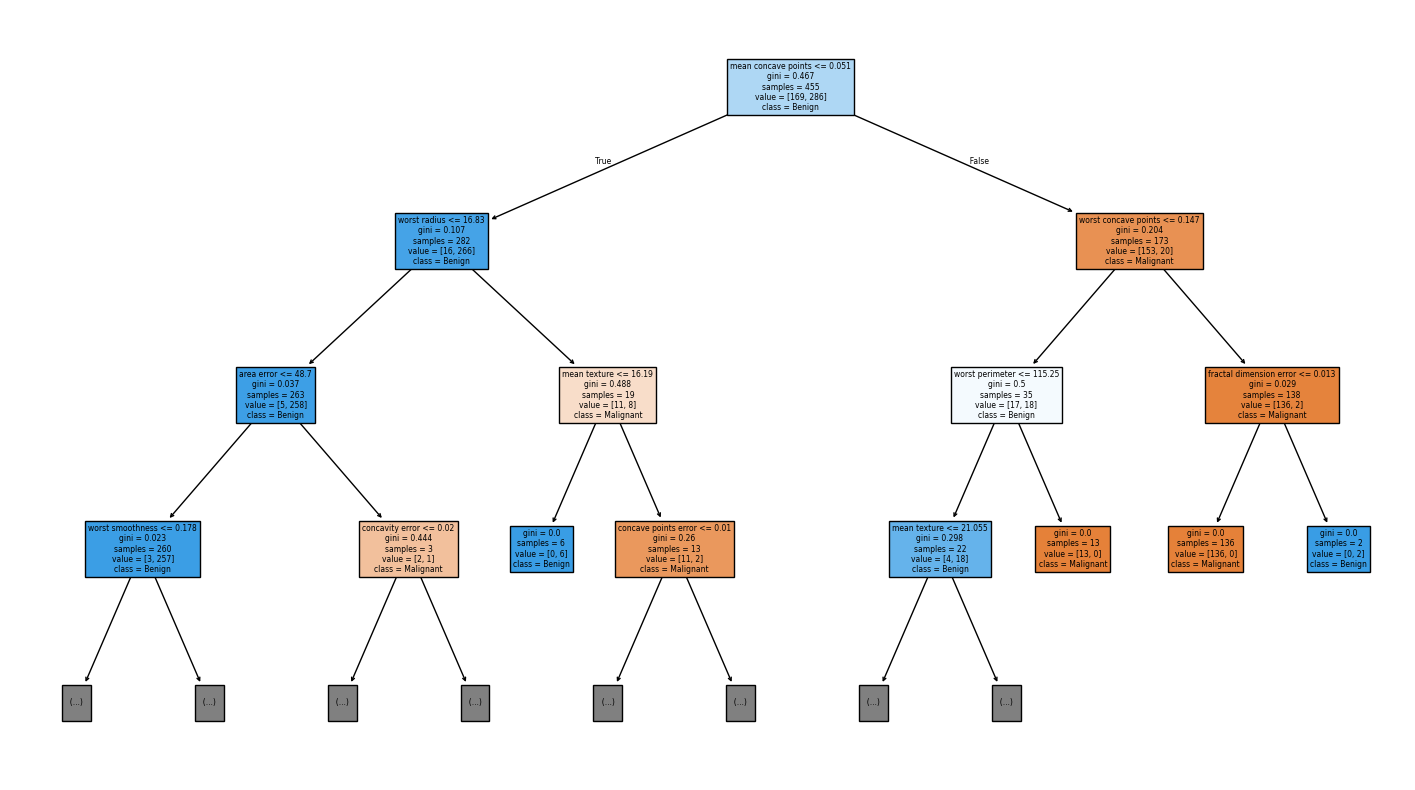

In [14]:
plt.figure(figsize=(18,10))

plot_tree(
    dt,
    filled=True,
    max_depth=3,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"]
)

plt.show()

## Overfitting Analysis

We train Decision Trees with different maximum depths and compare training and testing accuracy.

In [15]:
depths = [2, 4, 6, 8, None]

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"Max Depth = {depth}")
    print(f"Training Accuracy = {train_acc:.4f}")
    print(f"Testing Accuracy = {test_acc:.4f}")
    print("-"*40)

Max Depth = 2
Training Accuracy = 0.9297
Testing Accuracy = 0.9298
----------------------------------------
Max Depth = 4
Training Accuracy = 0.9956
Testing Accuracy = 0.9474
----------------------------------------
Max Depth = 6
Training Accuracy = 0.9978
Testing Accuracy = 0.9386
----------------------------------------
Max Depth = 8
Training Accuracy = 1.0000
Testing Accuracy = 0.9474
----------------------------------------
Max Depth = None
Training Accuracy = 1.0000
Testing Accuracy = 0.9474
----------------------------------------


## Training a Random Forest Classifier

Random Forest combines multiple Decision Trees and usually provides better generalization.

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.9649


## Comparing Model Accuracy

Comparing Decision Tree and Random Forest performance.

In [17]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.947368
1,Random Forest,0.964912


## Feature Importance

Feature importance indicates which features contribute most to the model's predictions.

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


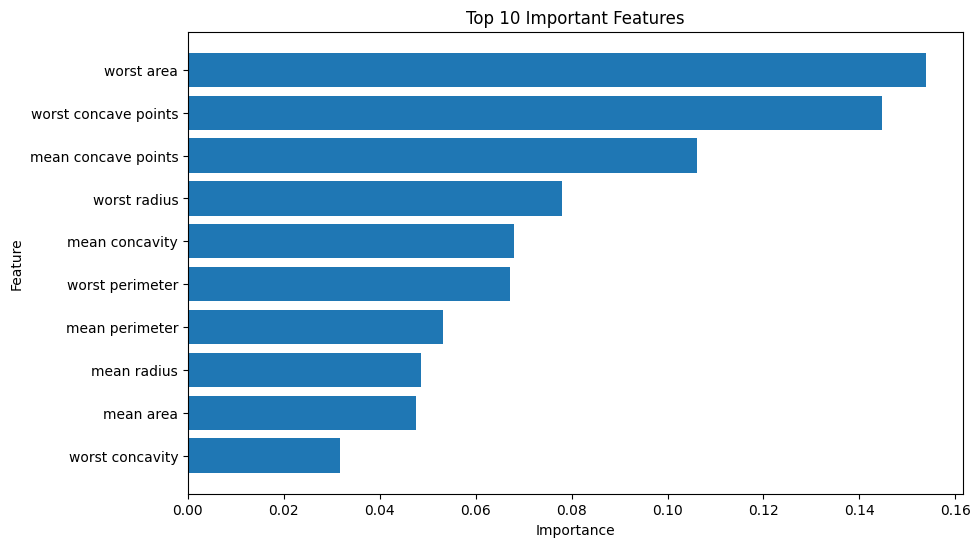

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## Cross Validation

Cross-validation provides a more reliable estimate of model performance by evaluating the model on multiple subsets of the data.

In [20]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:")
print(round(cv_scores.mean(), 4))

Cross Validation Scores:
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]

Average CV Accuracy:
0.9561


## Conclusion

1. Decision Trees are simple and easy to interpret.
2. Deep trees may overfit the training data.
3. Random Forest reduces overfitting by combining multiple trees.
4. Random Forest achieved better generalization performance.
5. Feature importance helps identify the most influential features.
6. Cross-validation provides a robust evaluation of model performance.